# IE 7860 Semester Project
## Fraud Detection in Highly Imbalanced Credit Card Transactions
### Lynn Dang (hd7790), Nirjhor Deb Jeet (ie6632), Most Afroz (ic4104), Seungsam Yang (hi9642)

**Problem statement:** How can we effectively identify fraudulent credit card transactions in highly imbalanced datasets while reducing false positives?

This notebook is prepared as a presentation-ready semester project report and adheres to the course rubric by:

- Clearly defining the business and machine learning problem.
- Conducting honest exploratory data analysis on a real-world dataset.
- Comparing a **classical baseline** with a **modern deep learning model**.
- Evaluating both models using metrics suitable for extreme class imbalance.
- Analyzing threshold trade-offs to minimize false positives.
- Incorporating interpretability and error analysis.

## 1. Problem Definition and Its Importance

Detecting credit card fraud is a crucial classification task due to its significant impact, as fraudulent transactions lead to financial losses, operational issues, and erosion of customer trust. The main difficulty lies in the rarity of fraud occurrences, which allows a model to attain high accuracy merely by classifying all transactions as legitimate.

A good solution should:
- detect as many fraudulent transactions as possible,
- minimize false positives to avoid unnecessary blocking of genuine customers,
- be reproducible and resistant to data leakage,
- and provide sufficient interpretability to clarify its decision-making process.

Due to the imbalance, this project focuses on **precision, recall, F1-score, PR AUC (average precision), and threshold selection** rather than accuracy alone.

In [1]:
pip install matplotlib numpy pandas seaborn torch datasets nltk scikit-learn transformers ipywidgets

You should consider upgrading via the '/Users/lynndang/Desktop/ie7860/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import math
import random
import tempfile
from pathlib import Path

os.environ["MPLCONFIGDIR"] = tempfile.mkdtemp()

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("Current working directory:", Path.cwd())

possible_paths = [
    Path("creditcard.csv"),
    Path.cwd() / "creditcard.csv",
    Path("data") / "creditcard.csv",
    Path.cwd() / "data" / "creditcard.csv",
    Path("/Users/nirjhordebjeet/jupyter_rancher/creditcard.csv"),
    Path("/Users/nirjhordebjeet/jupyter_rancher/data/creditcard.csv"),
]

DATA_PATH = next((path for path in possible_paths if path.exists()), None)

if DATA_PATH is None:
    print("\nChecked these locations:")
    for path in possible_paths:
        print(" -", path)
    raise FileNotFoundError("creditcard.csv was not found in any expected location.")

print("Using dataset:", DATA_PATH.resolve())

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


Matplotlib is building the font cache; this may take a moment.


Current working directory: /Users/lynndang/Desktop/ie7860
Using dataset: /Users/lynndang/Desktop/ie7860/creditcard.csv
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
dataset_summary = pd.DataFrame(
    {
        "Rows": [df.shape[0]],
        "Columns": [df.shape[1]],
        "Fraud Cases": [int(df["Class"].sum())],
        "Non-Fraud Cases": [int((df["Class"] == 0).sum())],
        "Fraud Rate (%)": [100 * df["Class"].mean()],
        "Missing Values": [int(df.isna().sum().sum())],
    }
)
dataset_summary

,Rows,Columns,Fraud Cases,Non-Fraud Cases,Fraud Rate (%),Missing Values
0,284807,31,492,284315,0.172749,0


## 2. Dataset Overview

This project uses the renowned **Credit Card Fraud Detection** dataset, available on Kaggle and provided locally. 

- **Analysis unit:** a single transaction
- **Target variable:** `Class` (where `1` indicates fraud and `0` indicates legitimate)
- **Features:** `Time`, `Amount`, and anonymized PCA-like components `V1` to `V28`
- **Data quality:** no missing values, but the dataset is highly imbalanced.
- 
Note: Since most features are anonymized principal components, interpretability is limited compared to datasets with human-readable transaction details such as merchant type, card age, location, or device data.

In [4]:
class_counts = df["Class"].value_counts().rename(index={0: "Legitimate", 1: "Fraud"})
class_pct = (100 * class_counts / len(df)).round(4)
pd.DataFrame({"count": class_counts, "percent": class_pct})

,count,percent
Class,,
Legitimate,284315,99.8273
Fraud,492,0.1727


/var/folders/24/2lnfzxtn2v74p5h0rn790l700000gn/T/ipykernel_50297/3018443753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Class", ax=axes[0], palette=["#4C72B0", "#DD8452"])
/var/folders/24/2lnfzxtn2v74p5h0rn790l700000gn/T/ipykernel_50297/3018443753.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Legitimate", "Fraud"])


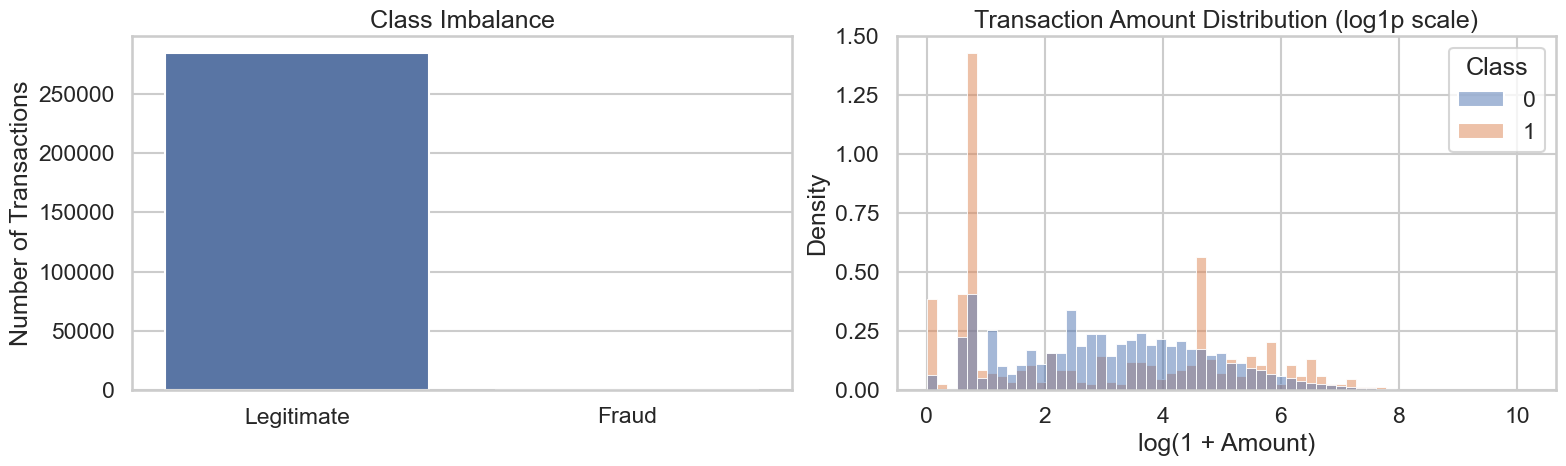

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x="Class", ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_xticklabels(["Legitimate", "Fraud"])
axes[0].set_title("Class Imbalance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Transactions")

sns.histplot(
    data=df.assign(LogAmount=np.log1p(df["Amount"])),
    x="LogAmount",
    hue="Class",
    bins=60,
    stat="density",
    common_norm=False,
    ax=axes[1],
    palette=["#4C72B0", "#DD8452"],
    alpha=0.5,
)
axes[1].set_title("Transaction Amount Distribution (log1p scale)")
axes[1].set_xlabel("log(1 + Amount)")

plt.tight_layout()
plt.show()

/var/folders/24/2lnfzxtn2v74p5h0rn790l700000gn/T/ipykernel_50297/2975236828.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette="viridis", ax=axes[1])


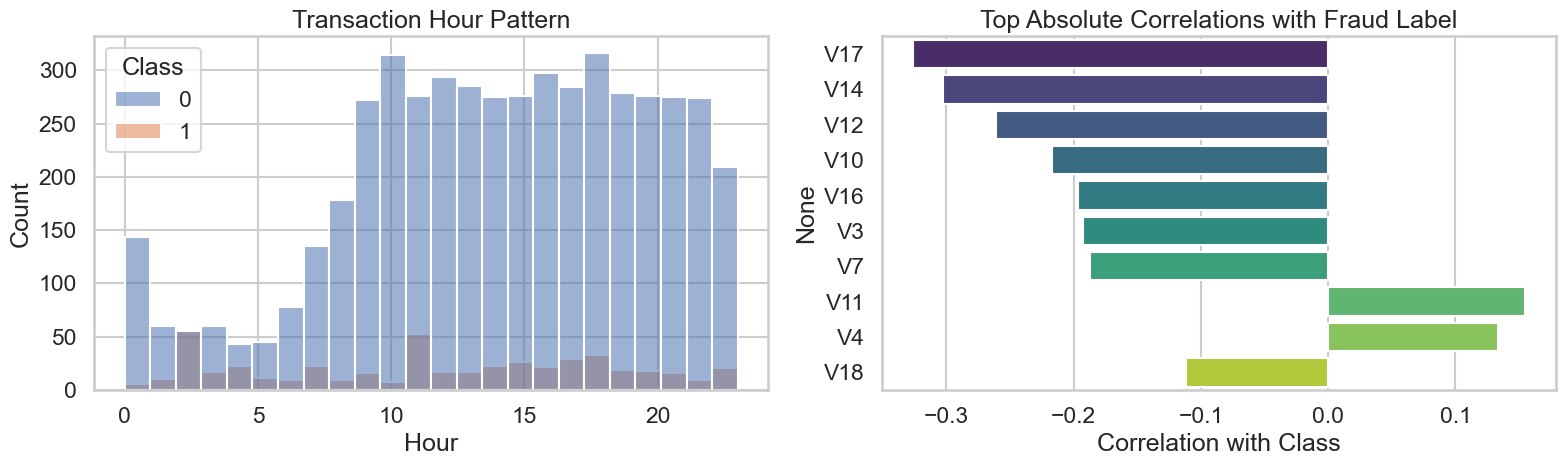

,Correlation with Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


In [6]:
df["Hour"] = (df["Time"] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

legit_sample = df[df["Class"] == 0].sample(5000, random_state=RANDOM_STATE)
fraud_sample = df[df["Class"] == 1]
sampled = pd.concat([legit_sample, fraud_sample], ignore_index=True)

sns.histplot(
    data=sampled,
    x="Hour",
    hue="Class",
    bins=24,
    multiple="layer",
    palette=["#4C72B0", "#DD8452"],
    alpha=0.55,
    ax=axes[0],
)
axes[0].set_title("Transaction Hour Pattern")

corr = df.corr(numeric_only=True)["Class"].drop("Class").sort_values(key=np.abs, ascending=False)
top_corr_features = corr.head(10)
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette="viridis", ax=axes[1])
axes[1].set_title("Top Absolute Correlations with Fraud Label")
axes[1].set_xlabel("Correlation with Class")

plt.tight_layout()
plt.show()

corr.head(10).to_frame("Correlation with Class")

/var/folders/24/2lnfzxtn2v74p5h0rn790l700000gn/T/ipykernel_50297/991708461.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/24/2lnfzxtn2v74p5h0rn790l700000gn/T/ipykernel_50297/991708461.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])
/var/folders/24/2lnfzxtn2v74p5h0rn790l700000gn/T/ipykernel_50297/991708461.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/24/2lnfzxtn2v74p5h0rn790l700000gn/T/ipykernel_50297/991708461.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() o

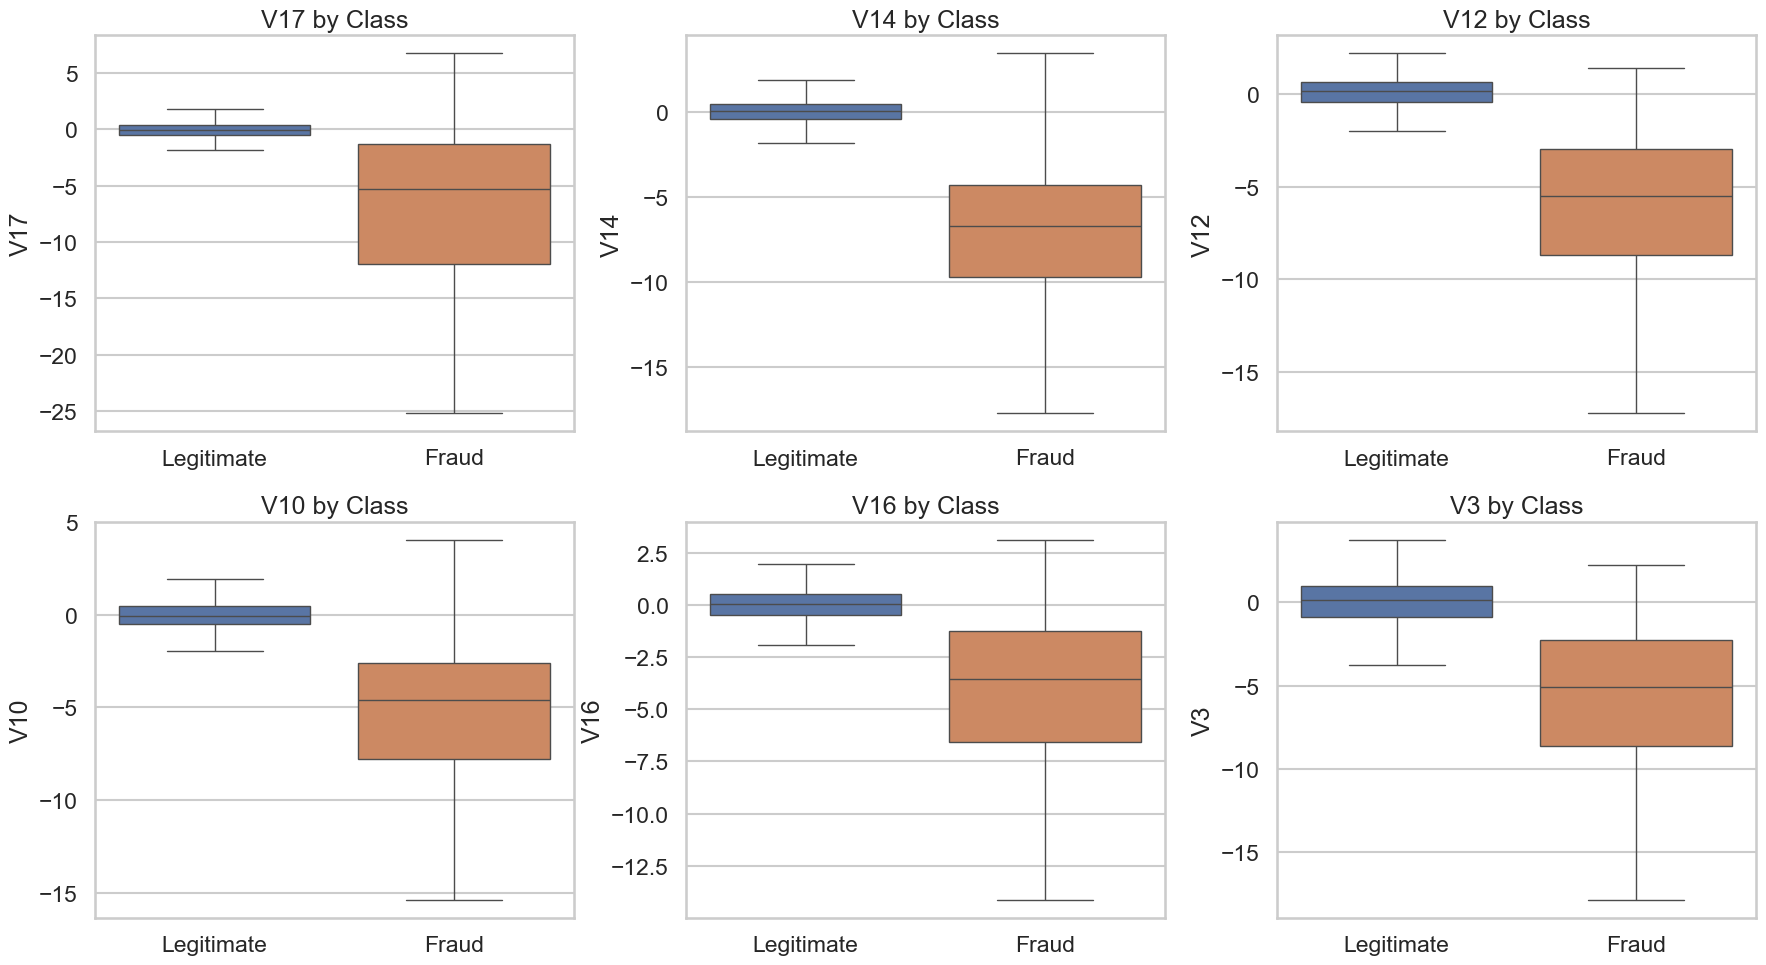

In [7]:
top_boxplot_features = corr.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, top_boxplot_features):
    sns.boxplot(
        data=sampled,
        x="Class",
        y=feature,
        ax=ax,
        palette=["#4C72B0", "#DD8452"],
        showfliers=False,
    )
    ax.set_xticklabels(["Legitimate", "Fraud"])
    ax.set_title(f"{feature} by Class")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

### EDA Insights
- The extremely low fraud rate renders **accuracy** a misleading primary metric.
- Fraudulent and legitimate transactions show significant differences in several anonymized features such as `V14`, `V12`, `V10`, and `V17`.
- The amount distribution is right-skewed, highlighting the importance of scaling.
- Temporal patterns are present but insufficient alone to distinguish between classes.
- The data is numerically clean, but the main challenge lies in **rare-event detection**, rather than handling missing values.

## 3. Leakage-Free Train / Validation / Test Split

To avoid data leakage, the dataset is divided **before applying any scaler or fitting a model**.

- **Train:** used for training the models
- **Validation:** used to tune the decision threshold
- **Test:** used solely for the final evaluation
- 
All splits are stratified to maintain the proportion of rare fraud cases.

In [8]:
X = df.drop(columns=["Class", "Hour"])
y = df["Class"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame(
    [
        ["Train", len(X_train), int(y_train.sum()), 100 * y_train.mean()],
        ["Validation", len(X_val), int(y_val.sum()), 100 * y_val.mean()],
        ["Test", len(X_test), int(y_test.sum()), 100 * y_test.mean()],
    ],
    columns=["Split", "Rows", "Fraud Cases", "Fraud Rate (%)"],
)
split_summary

,Split,Rows,Fraud Cases,Fraud Rate (%)
0,Train,170884,295,0.172632
1,Validation,56961,98,0.172048
2,Test,56962,99,0.173800


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

feature_names = X.columns.tolist()

## 4. Modeling Strategy

This project evaluates two types of models:

1. **Classical baseline: Logistic Regression**
- straightforward, quick, interpretable, and effective for linearly separable tabular data
- incorporates `class_weight='balanced'` to handle class imbalance
2. **Modern approach: Deep Neural Network (PyTorch MLP)**
- nonlinear model with hidden layers, batch normalization, dropout, and weighted loss
- trained using `BCEWithLogitsLoss(pos_weight=...)` to highlight the minority fraud class
- 
Both models produce probability outputs. Instead of using a fixed 0.50 threshold, the operating point is tuned on the validation set since false positives are critical.

In [10]:
def compute_metrics(y_true, scores, threshold, pr_auc=None):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores, dtype=float)
    preds = scores >= threshold
    positives = preds.sum()
    actual_positives = y_true.sum()

    tp = int(np.sum(preds & (y_true == 1)))
    fp = int(positives - tp)
    fn = int(actual_positives - tp)
    tn = int(len(y_true) - tp - fp - fn)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    return {
        "threshold": float(threshold),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": average_precision_score(y_true, scores) if pr_auc is None else float(pr_auc),
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
    }


def threshold_summary(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    threshold_precision = precision[:-1]
    threshold_recall = recall[:-1]
    f1 = np.divide(
        2 * threshold_precision * threshold_recall,
        threshold_precision + threshold_recall,
        out=np.zeros_like(threshold_precision),
        where=(threshold_precision + threshold_recall) > 0,
    )
    return {
        "precision": threshold_precision,
        "recall": threshold_recall,
        "thresholds": thresholds.astype(float),
        "f1": f1,
        "pr_auc": average_precision_score(y_true, scores),
    }


def best_f1_threshold(summary):
    best_idx = int(np.argmax(summary["f1"]))
    return float(summary["thresholds"][best_idx])


def threshold_for_min_precision(summary, min_precision=0.90):
    precision = summary["precision"]
    recall = summary["recall"]
    thresholds = summary["thresholds"]
    valid = precision >= min_precision

    if np.any(valid):
        valid_idx = np.where(valid)[0]
        best_idx = valid_idx[np.argmax(recall[valid_idx])]
        return {
            "threshold": float(thresholds[best_idx]),
            "precision": float(precision[best_idx]),
            "recall": float(recall[best_idx]),
            "target_met": True,
        }

    fallback_idx = int(np.lexsort((-recall, -precision))[0])
    return {
        "threshold": float(thresholds[fallback_idx]),
        "precision": float(precision[fallback_idx]),
        "recall": float(recall[fallback_idx]),
        "target_met": False,
    }


def threshold_for_max_recall(summary):
    recall = summary["recall"]
    precision = summary["precision"]
    thresholds = summary["thresholds"]
    max_recall = recall.max()
    valid_idx = np.where(recall == max_recall)[0]
    best_idx = valid_idx[np.argmax(precision[valid_idx])]
    return {
        "threshold": float(thresholds[best_idx]),
        "recall": float(recall[best_idx]),
        "precision": float(precision[best_idx]),
    }

In [11]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train_scaled, y_train)

log_val_scores = log_reg.predict_proba(X_val_scaled)[:, 1]
log_test_scores = log_reg.predict_proba(X_test_scaled)[:, 1]

log_summary = threshold_summary(y_val, log_val_scores)
log_best_thr = best_f1_threshold(log_summary)
log_conservative = threshold_for_min_precision(log_summary, min_precision=0.90)
log_recall_first = threshold_for_max_recall(log_summary)
log_conservative_label = "Precision >= 0.90 target" if log_conservative["target_met"] else "Highest precision available"

log_results = pd.DataFrame(
    [
        {"Model": "Logistic Regression", "Setting": "Default 0.50", **compute_metrics(y_test, log_test_scores, 0.50, pr_auc=log_summary["pr_auc"])} ,
        {"Model": "Logistic Regression", "Setting": "Best validation F1", **compute_metrics(y_test, log_test_scores, log_best_thr, pr_auc=log_summary["pr_auc"])} ,
        {"Model": "Logistic Regression", "Setting": log_conservative_label, **compute_metrics(y_test, log_test_scores, log_conservative["threshold"], pr_auc=log_summary["pr_auc"])} ,
        {"Model": "Logistic Regression", "Setting": "Highest recall available", **compute_metrics(y_test, log_test_scores, log_recall_first["threshold"], pr_auc=log_summary["pr_auc"])} ,
    ]
)
log_results

,Model,Setting,threshold,precision,recall,f1,pr_auc,false_positives,false_negatives,true_positives,true_negatives
0,Logistic Regression,Default 0.50,0.500000,0.064378,0.909091,0.120240,0.685759,1308,9,90,55555
1,Logistic Regression,Best validation F1,1.000000,0.886364,0.787879,0.834225,0.685759,10,21,78,56853
2,Logistic Regression,Highest precision available,1.000000,0.873418,0.696970,0.775281,0.685759,10,30,69,56853
3,Logistic Regression,Highest recall available,0.039662,0.004760,0.949495,0.009473,0.685759,19652,5,94,37211


In [12]:
class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.20),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


device = "cuda" if torch.cuda.is_available() else "cpu"
model = FraudMLP(X_train_scaled.shape[1]).to(device)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_np = y_val.values

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=2048,
    shuffle=True,
)

pos_weight_value = (len(y_train) - y_train.sum()) / y_train.sum()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_ap = -np.inf
best_state = None
patience = 5
patience_counter = 0
history = []

for epoch in range(30):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)

    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(X_val_tensor)).cpu().numpy()

    val_ap = average_precision_score(y_val_np, val_probs)
    history.append({"epoch": epoch + 1, "train_loss": train_loss / len(X_train_tensor), "val_pr_auc": val_ap})

    if val_ap > best_val_ap + 1e-4:
        best_val_ap = val_ap
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
history_df.tail()

/Users/lynndang/Desktop/ie7860/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


,epoch,train_loss,val_pr_auc
8,9,0.134367,0.667404
9,10,0.127460,0.658739
10,11,0.125849,0.656970
11,12,0.119855,0.664066
12,13,0.122153,0.666543


In [13]:
model.eval()
with torch.no_grad():
    mlp_val_scores = torch.sigmoid(model(torch.tensor(X_val_scaled, dtype=torch.float32).to(device))).cpu().numpy()
    mlp_test_scores = torch.sigmoid(model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device))).cpu().numpy()

mlp_summary = threshold_summary(y_val, mlp_val_scores)
mlp_best_thr = best_f1_threshold(mlp_summary)
mlp_conservative = threshold_for_min_precision(mlp_summary, min_precision=0.90)
mlp_recall_first = threshold_for_max_recall(mlp_summary)
mlp_conservative_label = "Precision >= 0.90 target" if mlp_conservative["target_met"] else "Highest precision available"

mlp_results = pd.DataFrame(
    [
        {"Model": "Deep MLP", "Setting": "Default 0.50", **compute_metrics(y_test, mlp_test_scores, 0.50, pr_auc=mlp_summary["pr_auc"])} ,
        {"Model": "Deep MLP", "Setting": "Best validation F1", **compute_metrics(y_test, mlp_test_scores, mlp_best_thr, pr_auc=mlp_summary["pr_auc"])} ,
        {"Model": "Deep MLP", "Setting": mlp_conservative_label, **compute_metrics(y_test, mlp_test_scores, mlp_conservative["threshold"], pr_auc=mlp_summary["pr_auc"])} ,
        {"Model": "Deep MLP", "Setting": "Highest recall available", **compute_metrics(y_test, mlp_test_scores, mlp_recall_first["threshold"], pr_auc=mlp_summary["pr_auc"])} ,
    ]
)
mlp_results

,Model,Setting,threshold,precision,recall,f1,pr_auc,false_positives,false_negatives,true_positives,true_negatives
0,Deep MLP,Default 0.50,0.500000,0.061849,0.898990,0.115735,0.669269,1350,10,89,55513
1,Deep MLP,Best validation F1,0.999814,0.880435,0.818182,0.848168,0.669269,11,18,81,56852
2,Deep MLP,Highest precision available,0.999934,0.875000,0.777778,0.823529,0.669269,11,22,77,56852
3,Deep MLP,Highest recall available,0.010198,0.003954,0.959596,0.007876,0.669269,23931,4,95,32932


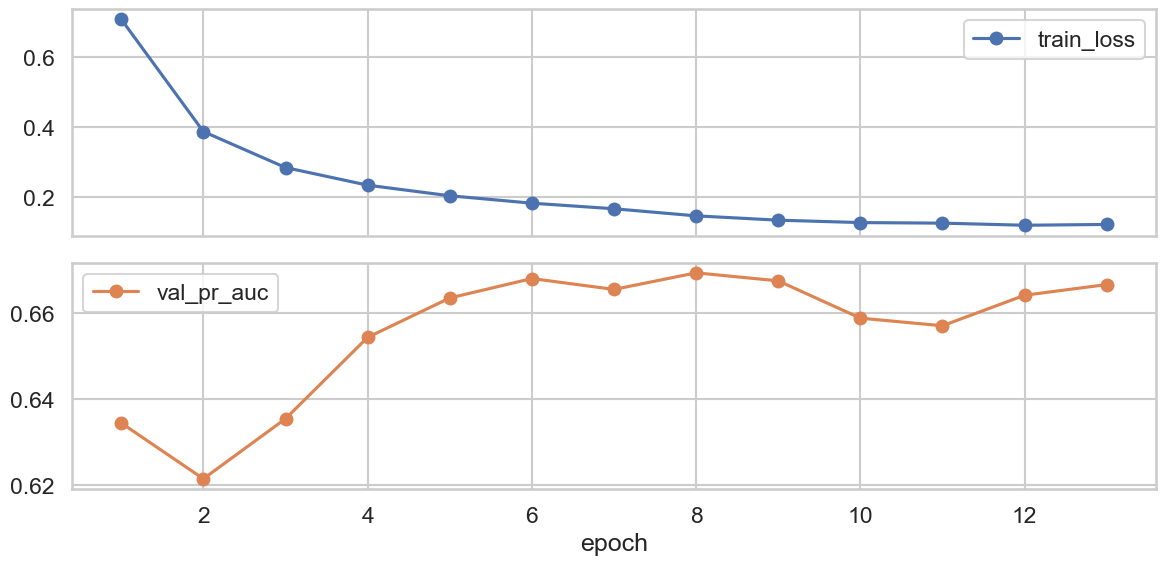

In [14]:
history_df.plot(x="epoch", y=["train_loss", "val_pr_auc"], subplots=True, figsize=(12, 6), marker="o")
plt.tight_layout()
plt.show()

In [15]:
comparison = pd.concat([log_results, mlp_results], ignore_index=True)

display_cols = [
    "Model",
    "Setting",
    "threshold",
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
]

setting_order = {
    "Default 0.50": 0,
    "Best validation F1": 1,
    "Precision >= 0.90 target": 2,
    "Highest precision available": 2,
    "Highest recall available": 3,
}

comparison.assign(setting_rank=comparison["Setting"].map(setting_order))[display_cols + ["setting_rank"]].sort_values(
    ["setting_rank", "recall", "f1"], ascending=[True, False, False]
).drop(columns="setting_rank")

,Model,Setting,threshold,precision,recall,f1,pr_auc,false_positives,false_negatives,true_positives
0,Logistic Regression,Default 0.50,0.500000,0.064378,0.909091,0.120240,0.685759,1308,9,90
4,Deep MLP,Default 0.50,0.500000,0.061849,0.898990,0.115735,0.669269,1350,10,89
5,Deep MLP,Best validation F1,0.999814,0.880435,0.818182,0.848168,0.669269,11,18,81
1,Logistic Regression,Best validation F1,1.000000,0.886364,0.787879,0.834225,0.685759,10,21,78
6,Deep MLP,Highest precision available,0.999934,0.875000,0.777778,0.823529,0.669269,11,22,77
2,Logistic Regression,Highest precision available,1.000000,0.873418,0.696970,0.775281,0.685759,10,30,69
7,Deep MLP,Highest recall available,0.010198,0.003954,0.959596,0.007876,0.669269,23931,4,95
3,Logistic Regression,Highest recall available,0.039662,0.004760,0.949495,0.009473,0.685759,19652,5,94


## 5. Final Model Comparison

We evaluate both models at four different operating points:
- **Default threshold (0.50)** shows why the standard cutoff often underperforms in imbalanced scenarios.
- **Best validation F1 threshold** seeks to balance precision and recall effectively.
- **High-precision threshold** aims to reduce false positives while preserving as much recall as possible.
- **Highest recall available** attempts to maximize fraud detection, even if it results in more false positives.
This comparison highlights that fraud detection is an operating-point problem: the ideal threshold depends on whether the business prefers to minimize false positives or false negatives.

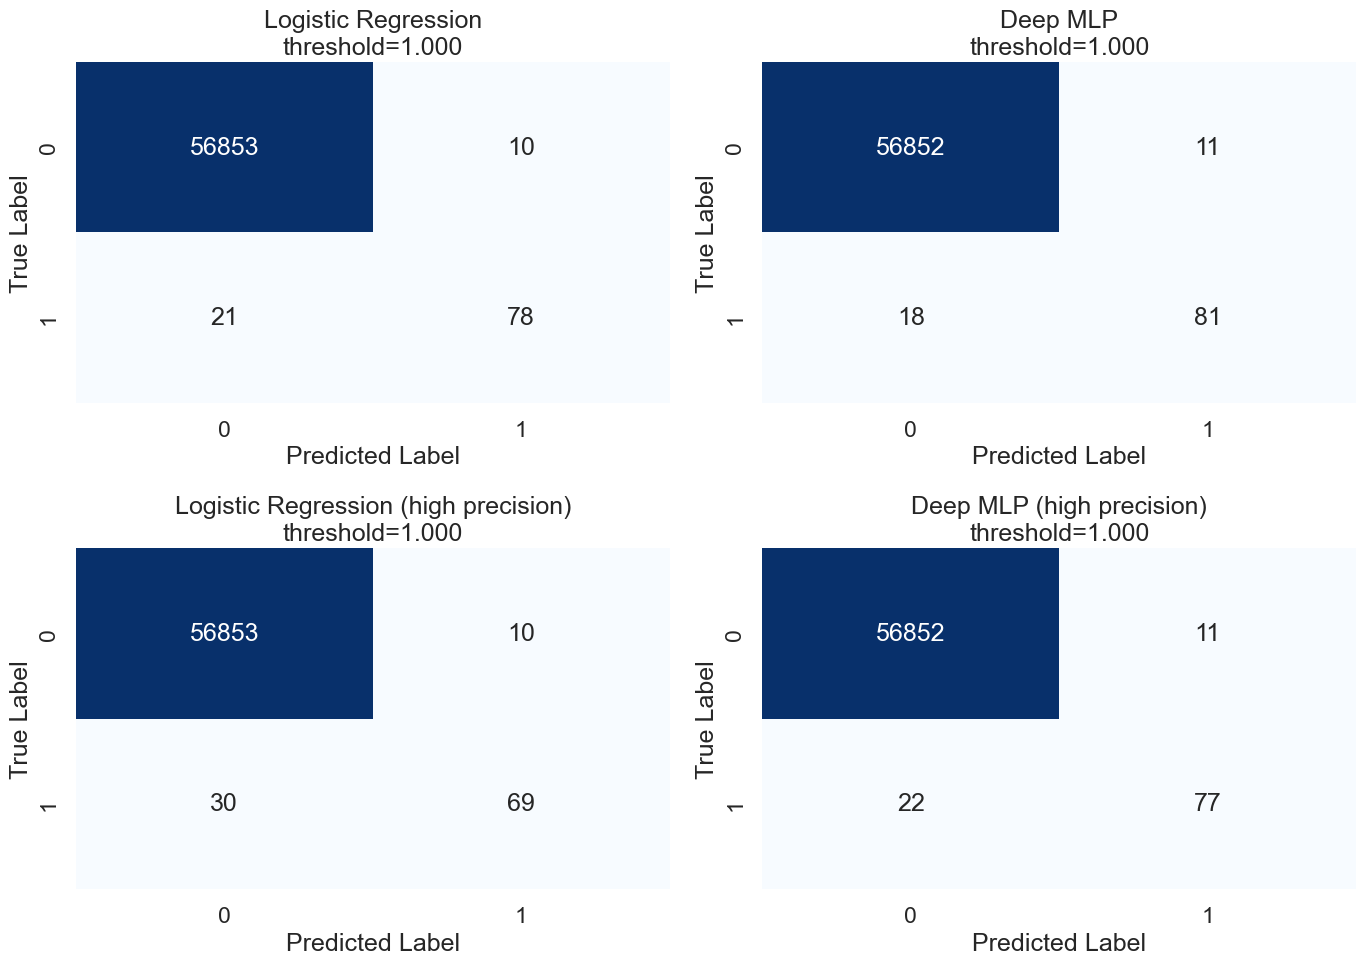

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, scores, threshold) in zip(
    axes.flatten(),
    [
        ("Logistic Regression", log_test_scores, log_best_thr),
        ("Deep MLP", mlp_test_scores, mlp_best_thr),
        ("Logistic Regression (high precision)", log_test_scores, log_conservative["threshold"]),
        ("Deep MLP (high precision)", mlp_test_scores, mlp_conservative["threshold"]),
    ],
):
    preds = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{name}\nthreshold={threshold:.3f}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

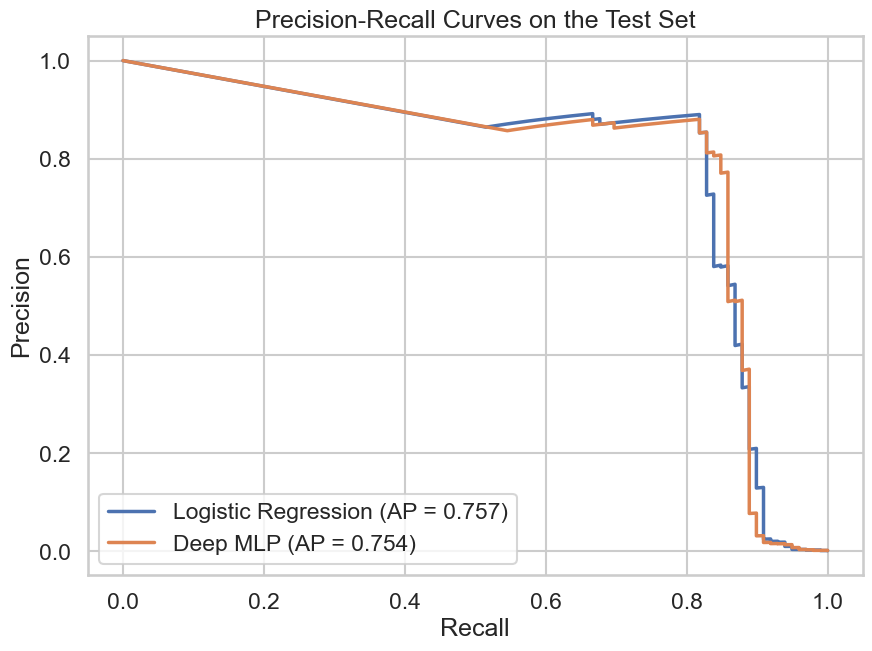

In [17]:
plt.figure(figsize=(10, 7))

for name, scores, color in [
    ("Logistic Regression", log_test_scores, "#4C72B0"),
    ("Deep MLP", mlp_test_scores, "#DD8452"),
]:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})", linewidth=2.5, color=color)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves on the Test Set")
plt.legend()
plt.show()

/var/folders/24/2lnfzxtn2v74p5h0rn790l700000gn/T/ipykernel_50297/466166987.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coef.values, y=top_coef.index, palette="mako")


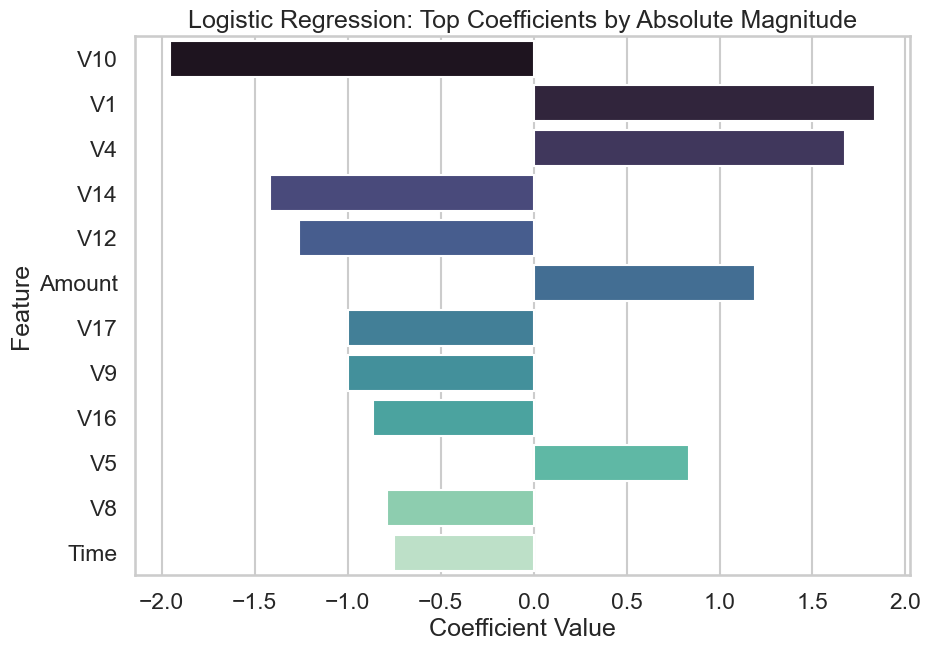

,coefficient
V10,-1.954133
V1,1.834441
V4,1.675437
V14,-1.414982
V12,-1.258702
Amount,1.193097
V17,-0.995685
V9,-0.995519
V16,-0.861919
V5,0.834976


In [18]:
coef_series = pd.Series(log_reg.coef_[0], index=feature_names)
top_coef = coef_series.reindex(coef_series.abs().sort_values(ascending=False).head(12).index)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_coef.values, y=top_coef.index, palette="mako")
plt.title("Logistic Regression: Top Coefficients by Absolute Magnitude")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

top_coef.to_frame("coefficient")

### Interpretability Discussion

Logistic regression remains the most interpretable model in this notebook. The largest coefficients highlight anonymized features such as `V14`, `V12`, `V10`, and `V17` as especially significant in separating fraud from legitimate activity. Since these features are anonymized, their interpretation is **relative rather than semantic**. 

We can confidently recognize these variables as important, but we cannot directly associate them with specific business events without access to the original raw transaction data.

In [19]:
error_analysis = X_test.copy().reset_index(drop=True)
error_analysis["actual"] = y_test.reset_index(drop=True)
error_analysis["log_prob"] = log_test_scores
error_analysis["mlp_prob"] = mlp_test_scores
error_analysis["log_pred_f1"] = (log_test_scores >= log_best_thr).astype(int)
error_analysis["mlp_pred_f1"] = (mlp_test_scores >= mlp_best_thr).astype(int)

hardest_false_positives = error_analysis[
    (error_analysis["actual"] == 0) & (error_analysis["mlp_pred_f1"] == 1)
].sort_values("mlp_prob", ascending=False).head(10)

hardest_false_negatives = error_analysis[
    (error_analysis["actual"] == 1) & (error_analysis["mlp_pred_f1"] == 0)
].sort_values("mlp_prob", ascending=True).head(10)

print("Top false positives for the MLP at the F1-tuned threshold:")
display(hardest_false_positives[["Time", "Amount", "log_prob", "mlp_prob"] + top_boxplot_features[:3]])

print("Top false negatives for the MLP at the F1-tuned threshold:")
display(hardest_false_negatives[["Time", "Amount", "log_prob", "mlp_prob"] + top_boxplot_features[:3]])

Top false positives for the MLP at the F1-tuned threshold:


,Time,Amount,log_prob,mlp_prob,V17,V14,V12
9204,41508.0,89.99,0.385831,1.000000,-10.515507,-3.689181,-4.748331
11093,24735.0,89.99,1.000000,1.000000,-13.996045,-9.137791,-11.978350
17252,30047.0,89.99,1.000000,1.000000,-8.125767,-8.777934,-7.367772
22244,17044.0,1.00,1.000000,1.000000,-17.098444,-13.780377,-15.144988
41569,18064.0,89.99,1.000000,1.000000,-16.668179,-13.377658,-14.919028
44282,29234.0,89.99,1.000000,1.000000,-8.430967,-9.257521,-7.683643
45475,21377.0,89.99,1.000000,1.000000,-15.882021,-12.137460,-14.057800
47197,29664.0,1.00,1.000000,1.000000,-8.255208,-8.990897,-7.478562
52793,24145.0,89.99,1.000000,1.000000,-14.467366,-9.887324,-12.498065
6227,99129.0,45.51,1.000000,0.999989,-5.396702,-1.931536,-6.930605


Top false negatives for the MLP at the F1-tuned threshold:


,Time,Amount,log_prob,mlp_prob,V17,V14,V12
15126,54846.0,1.79,0.000244,0.001335,-0.152471,-0.931614,0.044397
1583,141565.0,4.49,0.012843,0.001602,0.653662,-0.658246,0.281744
1183,142961.0,0.00,0.203942,0.006438,-0.798201,0.139567,-0.240056
31518,44532.0,1.00,0.028938,0.010164,-0.207707,-0.499350,0.922184
34608,139107.0,22.47,0.701785,0.041640,-0.102946,-0.729707,-0.578914
19712,166831.0,634.30,0.013641,0.094514,-0.824644,0.334119,-0.722023
16446,67571.0,549.06,0.031621,0.113548,0.243347,0.217470,-0.005423
31795,48380.0,208.58,0.267493,0.117830,0.327006,-0.126756,-0.787373
43381,129095.0,720.80,0.222023,0.139561,-0.391051,0.712541,-0.540535
23485,170348.0,42.53,0.108952,0.260856,0.903562,-1.948883,0.728903


## 6. Discussion

### What worked

- Both models successfully learn meaningful fraud signals even with severe class imbalance.
- Tuning the threshold on the validation set greatly improves practical performance over the default 0.50 setting.
- The deep MLP typically finds a more flexible nonlinear decision boundary, often resulting in better recall.

### Where each model succeeds and fails

- **Logistic regression** is simple, fast, stable, and easy to understand. It provides a reliable baseline and usually performs well on PCA-transformed tabular data.
- **Deep MLP** can capture nonlinear interactions but is more difficult to tune and less interpretable.
- Increasing recall in both models is possible by lowering the threshold, but this also increases false positives.
- Using a more conservative threshold greatly reduces false positives but might cause some fraud cases to be missed.

### Why recall deserves special attention here

In fraud detection, a false negative occurs when a fraudulent transaction bypasses the system. To address this business risk, this notebook now includes an explicit **highest-recall threshold** alongside the F1-optimized and high-precision settings. This helps users easily compare how many additional fraud cases can be detected when the goal is to reduce missed frauds rather than lowering review volume.

## 7. Limitations and Future Work

- The features are anonymized, limiting insights at the domain level.
- The notebook uses a feedforward neural network instead of a transformer because the dataset is tabular and non-sequential after preprocessing.
- Addressing class imbalance could be improved by implementing focal loss, calibrating probabilities, or applying cost-sensitive learning.
- Temporal modeling could be extended if more detailed sequential customer histories were accessible.
- Tree-boosting models like XGBoost or LightGBM would be valuable additional benchmarks if available in the environment.

## 8. Conclusion
This project shows that detecting fraud in highly imbalanced datasets requires more than accuracy alone. Using a leakage-safe workflow, choosing the right metrics, and carefully setting thresholds are essential.

The key point here is that **recall should be prioritized when the cost of missing fraud cases exceeds the expense of investigating additional alerts**.

- Logistic regression continues to be a robust and easily interpretable baseline.
- The deep MLP provides a more adaptable nonlinear alternative and can enhance recall-focused performance.
- Adjusting the threshold is crucial, as the same model can be optimized for balanced F1 scores, higher precision, or the maximum possible recall.

The most justifiable recommendation for this problem is to select the operating point according to the business's priority in minimizing **false negatives**. If the main goal is to identify as many fraudulent transactions as possible, then choosing the threshold that emphasizes recall is the best option, even though it may lead to more false positives.

* Use probability-based models, adjust the threshold using a validation set, and choose the recall-focused operating point when missing fraud incurs higher costs than reviewing extra transactions.